**Project:** Extended State Estimation  
**Author:** Marin Dagron  
**Date:** January 2026  
**Context:** Industrial Project - CentraleSupélec  

---

## Description
This notebook implements a **Kalman Filter** to estimate the dynamic state of a power system (generators G1 and G2).

The objective is to reconstruct state variables from noisy measurements, in the presence of various load disturbances.

**Document Structure:**
1.  **Modeling:** Definition of system matrices and disturbances.
2.  **Algorithm:** Implementation of the filter's prediction/correction loop.
3.  **Simulation:** Generation of synthetic data (Ground Truth vs Measurements).
4.  **Analysis:** Comparison of estimated vs real states and calculation of the Signal-to-Noise Ratio (SNR).


--- 




### 1. Perturbation senarios 


In [17]:
import numpy as np
def get_disturbances(t, scenario, params):
    # Default values (Table 4.1 / Sections 4.2 & 4.3)
    p1l, p2l = params['g1']['PL'], params['g2']['PL'] # 400 and 600 MW 
    kl = params['KL'] # 3064 MW/rad

    if scenario == 'EL1': # Linear increase: 100 MW over 60s
        p1l = 400 + (10000 / 60) * min(t, 1)
    elif scenario == 'EL2': # Linear increase: 200 MW over 60s
        p1l = 400 + (200 / 60) * min(t, 60)
    elif scenario == 'SL1': # Load step at 15s: 500 MW
        if t >= 15: p1l = 500
    elif scenario == 'SL2': # Load step at 15s: 600 MW
        if t >= 15: p1l = 600
    elif scenario == 'PLT': # Line trip at 15s
        if t >= 15: kl = 1532 # Change from 3064 to 1532 MW/rad
    elif scenario == 'Random': # Random disturbances
        p1l = p1l + np.random.normal(0, 0.01) # 1% noise
        p2l = p2l + np.random.normal(0, p2l*0.01) # 1% noise

    return p1l, p2l, kl

### 2. Row model simulation 

In [18]:
params = {
    'f0': 50.0,
    'omega0': 2 * np.pi * 50.0,
    'KL': 3064.0,   # MW/rad (two lines)
    'Ks': 0.05,
    'g1': {
        'P0': 600.0, 'Pmin': 0.0, 'Pmax': 1000.0, 'Pr': 100.0,
        'J': 0.4, 'D': 0.04, 'alpha': 100.0, 'beta': 2000.0, 'PL': 400.0
    },
    'g2': {
        'P0': 400.0, 'Pmin': 0.0, 'Pmax': 600.0, 'Pr': 50.0,
        'J': 0.1, 'D': 0.02, 'alpha': 100.0, 'beta': 2000.0, 'PL': 600.0
    },
    't_event': 15.0,
    'scenario':  'Random' # Choices: 'EL1', 'EL2', 'SL1', 'SL2', 'PLT', 'Random'
}

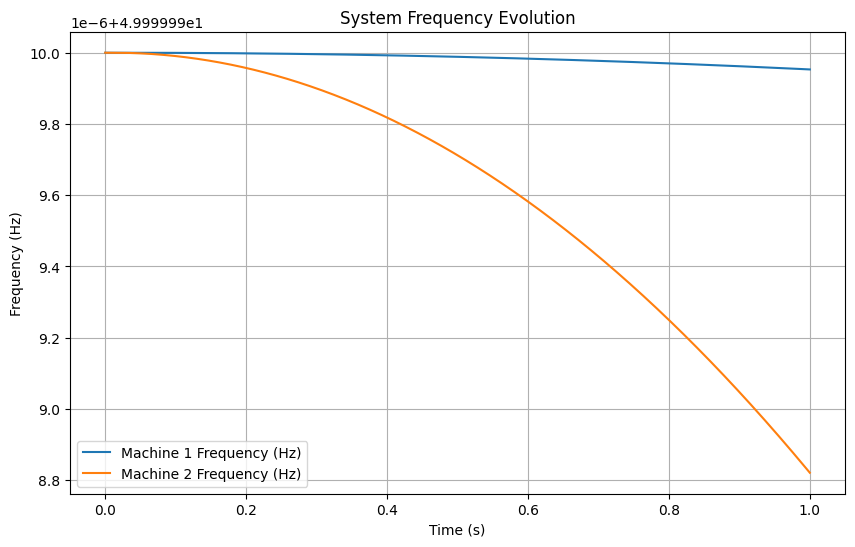

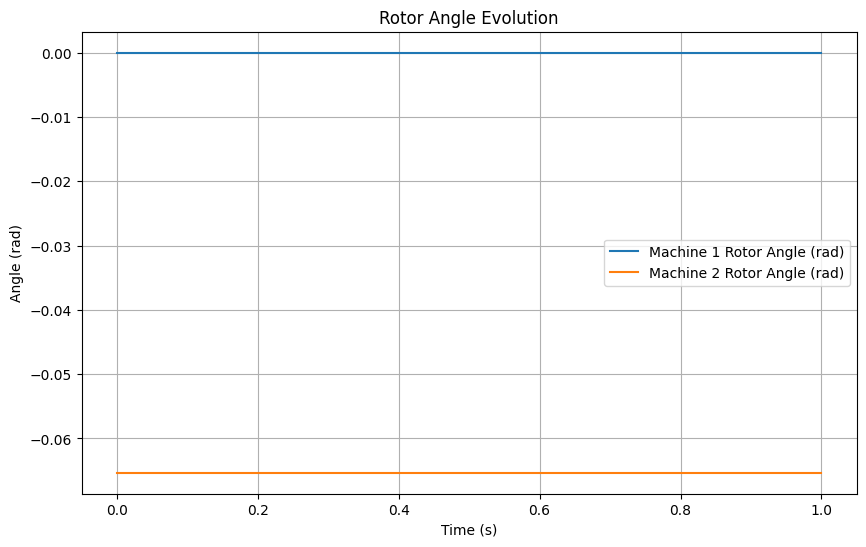

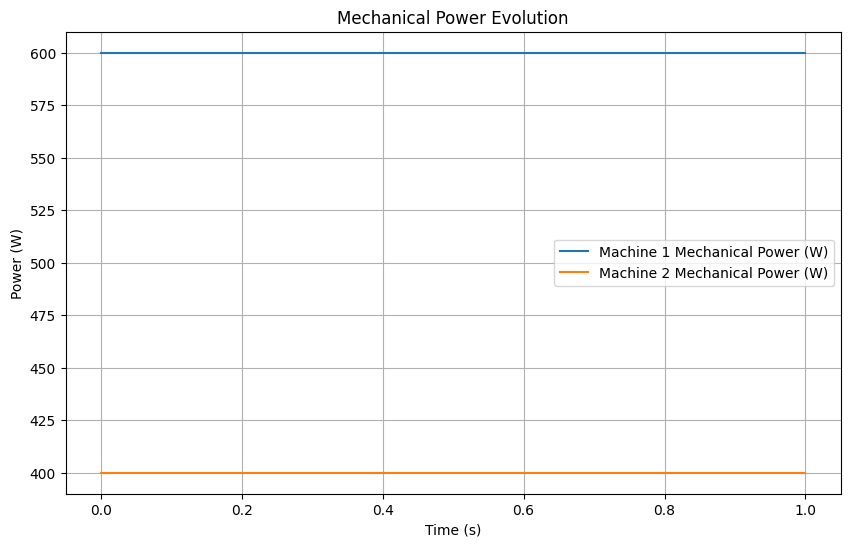

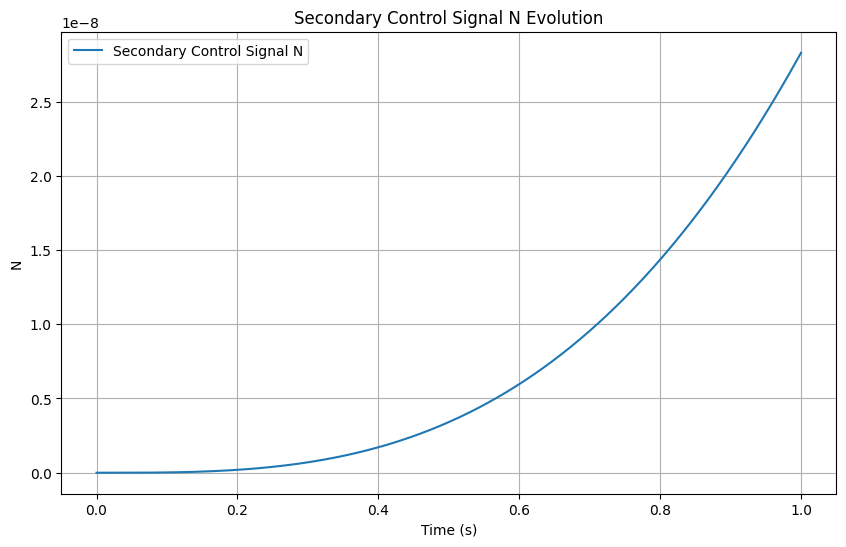

In [19]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def power_system_model(t, x, params):
    
    theta1, omega1, T1m, theta2, omega2, T2m, N = x
    # Ensure get_disturbances is defined in your scope or imported
    p1l , p2l, kl = get_disturbances(t, params['scenario'], params)
    w0 = params['omega0']
    
    # --- Algebraic Equations ---
    # Exchanged Power (Line)
    F12 = kl * np.sin(theta1 - theta2)
    F21 = -F12
    
    # Power demand on generators (Load + Line)
    P1G = p1l + F12
    P2G = p2l + F21

    # Current mechanical power
    P1m = T1m * omega1
    P2m = T2m * omega2
    
    # Power Setpoint (Secondary control N included)
    P1c = np.clip(params['g1']['P0'] + N * params['g1']['Pr'], params['g1']['Pmin'], params['g1']['Pmax'])
    P2c = np.clip(params['g2']['P0'] + N * params['g2']['Pr'], params['g2']['Pmin'], params['g2']['Pmax'])

    # --- Differential Equations ---
    # Generator 1
    d_theta1 = omega1 - w0
    d_omega1 = (T1m - (P1G/omega1) - params['g1']['D']*(omega1 - w0)) / params['g1']['J']
    
    # G1 Primary Control (with saturation limits)
    if params['g1']['Pmin'] <= P1m <= params['g1']['Pmax']:
        d_T1m = -params['g1']['alpha'] * (P1m - P1c) - params['g1']['beta'] * (omega1 - w0)
    else:
        d_T1m = 0

    # Generator 2
    d_theta2 = omega2 - w0
    d_omega2 = (T2m - (P2G/omega2) - params['g2']['D']*(omega2 - w0)) / params['g2']['J']
    
    # G2 Primary Control
    if params['g2']['Pmin'] <= P2m <= params['g2']['Pmax']:
        d_T2m = -params['g2']['alpha'] * (P2m - P2c) - params['g2']['beta'] * (omega2 - w0)
    else:
        d_T2m = 0

    # Secondary Control (Weighted average frequency)
    omega_r = (params['g1']['J']*omega1 + params['g2']['J']*omega2) / (params['g1']['J'] + params['g2']['J'])
    if -1 <= N <= 1:
        dN = -params['Ks'] * (omega_r - w0)
    else:
        dN = 0

    return [d_theta1, d_omega1, d_T1m, d_theta2, d_omega2, d_T2m, dN]

# --- System Parameters ---
w0_rad = 2 * np.pi * 50



#--- Simulation ---
# Initial Conditions
# Equilibrium position
x0 = [0, w0_rad, params['g1']['P0']/w0_rad, -np.arcsin((params['g1']['P0'] - params['g1']['PL']) / params['KL']), w0_rad, params['g2']['P0']/w0_rad, 0] 
# Small initial perturbation (on theta2) - commented out
# x0 = [0, w0_rad, params['g1']['P0']/w0_rad, 0, w0_rad, params['g2']['P0']/w0_rad, 0] 

t_span = (0, 1)
t_eval = np.linspace(0, t_span[1], 1000)

sol = solve_ivp(power_system_model, t_span, x0, args=(params,), t_eval=t_eval, method='Radau')

theta1_sim = sol.y[0]
theta2_sim = sol.y[3]
F12_sim = params['KL'] * (theta1_sim - theta2_sim)
P1G_sim = params['g1']['PL'] + F12_sim
P2G_sim = params['g2']['PL'] + F12_sim

# --- Visualization ---
plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[1]/(2*np.pi), label='Machine 1 Frequency (Hz)')
plt.plot(sol.t, sol.y[4]/(2*np.pi), label='Machine 2 Frequency (Hz)')
plt.title("System Frequency Evolution")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0], label='Machine 1 Rotor Angle (rad)')
plt.plot(sol.t, sol.y[3], label='Machine 2 Rotor Angle (rad)')
plt.title("Rotor Angle Evolution")    
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[2]*sol.y[1], label='Machine 1 Mechanical Power (W)')
plt.plot(sol.t, sol.y[5]*sol.y[4], label='Machine 2 Mechanical Power (W)')
plt.title("Mechanical Power Evolution")       
plt.xlabel("Time (s)")
plt.ylabel("Power (W)")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[6], label='Secondary Control Signal N')
plt.title("Secondary Control Signal N Evolution")       
plt.xlabel("Time (s)")
plt.ylabel("N")
plt.grid(True)
plt.legend()
plt.show()

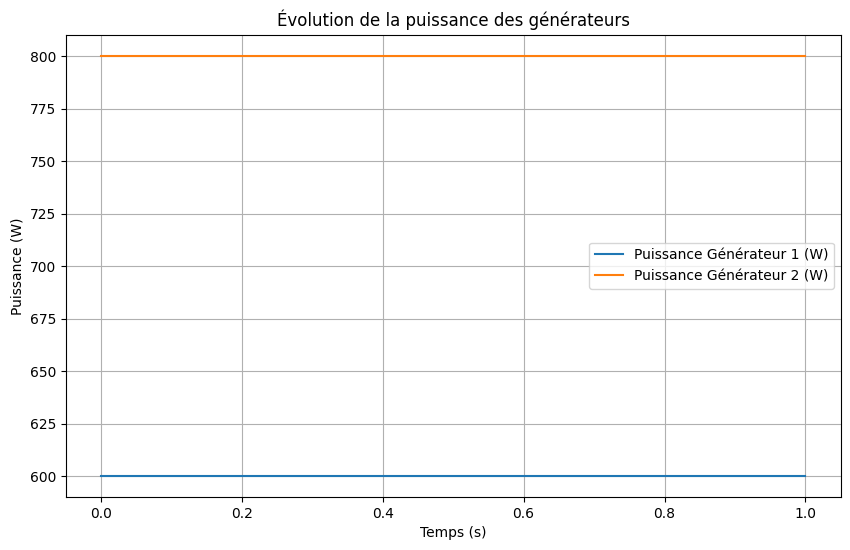

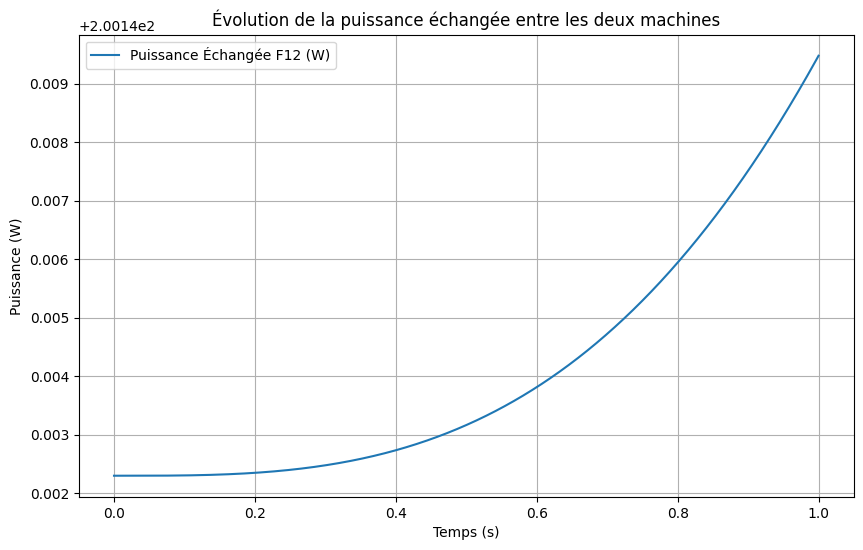

In [20]:
plt.figure(figsize=(10, 6)) 
plt.plot(sol.t, P1G_sim, label='Puissance Générateur 1 (W)')
plt.plot(sol.t, P2G_sim, label='Puissance Générateur 2 (W)')
plt.title("Évolution de la puissance des générateurs")  
plt.xlabel("Temps (s)")
plt.ylabel("Puissance (W)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(sol.t, F12_sim, label='Puissance Échangée F12 (W)')
plt.title("Évolution de la puissance échangée entre les deux machines")
plt.xlabel("Temps (s)")
plt.ylabel("Puissance (W)")
plt.grid(True)
plt.legend()
plt.show()

### 3. Linear system modelisation 

In [21]:
import sympy as sp
def linear_model(params):
    t1, w1, tm1, t2, w2, tm2, n = sp.symbols('theta1 omega1 Tm1 theta2 omega2 Tm2 N')
    p10, p20, pl1, pl2, pg1, pg2, kl, w0, j1, j2, d1, d2, a1, a2, b1, b2, pr1, pr2, ks = sp.symbols(
        'P10 P20 P1L P2L PG1 PG2 KL omega0 J1 J2 D1 D2 alpha1 alpha2 beta1 beta2 Pr1 Pr2 Ks'
    )

    # ---State vector---
    X = sp.Matrix([t1, w1, tm1, t2, w2, tm2, n, pl1, pl2]) 

    # --- System Equations ---
    f12 = kl * (t1 - t2) 
    pg1 = pl1 + f12
    pg2 = pl2 - f12

    f = sp.Matrix([
        w1 - w0,
        (tm1 - (pl1 + f12)/w0 - d1*(w1 - w0))/j1,
        -a1*(tm1*w0 - (p10 + n*pr1)) - b1*(w1 - w0),
        w2 - w0,
        (tm2 - (pl2 - f12)/w0 - d2*(w2 - w0))/j2,
        -a2*(tm2*w0 - (p20 + n*pr2)) - b2*(w2 - w0),
        -ks * ((j1*w1 + j2*w2)/(j1+j2) - w0),
        0,
        0
    ])

    # --- Outputs ---
    Y = sp.Matrix([ t1, t2 ,f12, pg1, pg2, pl1, pl2]) 

    # --- Compute Jacobians ---
    A_sym = f.jacobian(X)
    B_sym = f.jacobian(sp.Matrix([p10, p20]))
    D_sym = f.jacobian(sp.Matrix([pl1, pl2]))

    C_sym = Y.jacobian(X)
    E_sym = Y.jacobian(sp.Matrix([pl1, pl2]))

    print("Matrix A (First row):", A_sym)
    print("Matrix B(First row):", B_sym)
    print("Matrix D (First row):", D_sym)
    print("Matrix C (First row):", C_sym)
    print("Matrix E (First row):", E_sym)

    # --- Symbolic to Numeric ---
    subs_dict = {
        w0:  params['omega0'],
        kl:  params['KL'], 
        ks:  params['Ks'],
        # Générateur 1
        p10: params['g1']['P0'],
        pl1: params['g1']['PL'],
        j1:  params['g1']['J'],
        d1:  params['g1']['D'],
        a1:  params['g1']['alpha'],
        b1:  params['g1']['beta'],
        pr1: params['g1']['Pr'],
        # Générateur 2
        p20: params['g2']['P0'],
        pl2: params['g2']['PL'],
        j2:  params['g2']['J'],
        d2:  params['g2']['D'],
        a2:  params['g2']['alpha'],
        b2:  params['g2']['beta'],
        pr2: params['g2']['Pr']
    }

    A_num = np.array(A_sym.subs(subs_dict)).astype(np.float64)
    B_num = np.array(B_sym.subs(subs_dict)).astype(np.float64)
    C_num = np.array(C_sym.subs(subs_dict)).astype(np.float64)
    D_num = np.array(D_sym.subs(subs_dict)).astype(np.float64)
    E_num = np.array(E_sym.subs(subs_dict)).astype(np.float64)
    # E_num = np.zeros((Y.shape[0], 2)) # Since E_sym is not used, we set it to zero
    return X, Y, A_num, B_num, C_num, D_num, E_num





In [22]:
X, Y, A_num, B_num, C_num, D_num, E_num = linear_model(params)
print("Numeric A Matrix:\n", A_num)

# --- Numerical Observability Analysis ---
n = A_num.shape[0]

obs_blocks = [C_num @ np.linalg.matrix_power(A_num, i) for i in range(n)]
Obs_matrix = np.vstack(obs_blocks)
print("Observability Matrix:\n", Obs_matrix)
rank_obs = np.linalg.matrix_rank(Obs_matrix, tol=1e-8) # becarfull with tol that can change the result

print(f"Matrice d'observabilité (shape) : {Obs_matrix.shape}")
print(f"Rang de la matrice d'observation : {rank_obs}")
print(f"Dimension de l'état (n) : {n}")

if rank_obs == n:
    print("Le système est observable (rang plein).")
else:
    print(f"Le système n'est PAS observable ({n - rank_obs} modes inobservables).")

Matrix A (First row): Matrix([[0, 1, 0, 0, 0, 0, 0, 0, 0], [-KL/(J1*omega0), -D1/J1, 1/J1, KL/(J1*omega0), 0, 0, 0, -1/(J1*omega0), 0], [0, -beta1, -alpha1*omega0, 0, 0, 0, Pr1*alpha1, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0], [KL/(J2*omega0), 0, 0, -KL/(J2*omega0), -D2/J2, 1/J2, 0, 0, -1/(J2*omega0)], [0, 0, 0, 0, -beta2, -alpha2*omega0, Pr2*alpha2, 0, 0], [0, -J1*Ks/(J1 + J2), 0, 0, -J2*Ks/(J1 + J2), 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0]])
Matrix B(First row): Matrix([[0, 0], [0, 0], [alpha1, 0], [0, 0], [0, 0], [0, alpha2], [0, 0], [0, 0], [0, 0]])
Matrix D (First row): Matrix([[0, 0], [-1/(J1*omega0), 0], [0, 0], [0, 0], [0, -1/(J2*omega0)], [0, 0], [0, 0], [0, 0], [0, 0]])
Matrix C (First row): Matrix([[1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0, 0], [KL, 0, 0, -KL, 0, 0, 0, 0, 0], [KL, 0, 0, -KL, 0, 0, 0, 1, 0], [-KL, 0, 0, KL, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1]])
Matrix E (First row): Matrix([[0, 0], [0, 0]

### 4. Simulation of the linear system using Euler's metod

Initial state (x0): [ 0.00000000e+00  3.14159265e+02  1.90985932e+00 -6.53205930e-02
  3.14159265e+02  1.27323954e+00  0.00000000e+00  4.00000000e+02
  6.00000000e+02]
Matrix A (First row): Matrix([[0, 1, 0, 0, 0, 0, 0, 0, 0], [-KL/(J1*omega0), -D1/J1, 1/J1, KL/(J1*omega0), 0, 0, 0, -1/(J1*omega0), 0], [0, -beta1, -alpha1*omega0, 0, 0, 0, Pr1*alpha1, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0], [KL/(J2*omega0), 0, 0, -KL/(J2*omega0), -D2/J2, 1/J2, 0, 0, -1/(J2*omega0)], [0, 0, 0, 0, -beta2, -alpha2*omega0, Pr2*alpha2, 0, 0], [0, -J1*Ks/(J1 + J2), 0, 0, -J2*Ks/(J1 + J2), 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0]])
Matrix B(First row): Matrix([[0, 0], [0, 0], [alpha1, 0], [0, 0], [0, 0], [0, alpha2], [0, 0], [0, 0], [0, 0]])
Matrix D (First row): Matrix([[0, 0], [-1/(J1*omega0), 0], [0, 0], [0, 0], [0, -1/(J2*omega0)], [0, 0], [0, 0], [0, 0], [0, 0]])
Matrix C (First row): Matrix([[1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0, 0], [KL, 0, 0, -KL, 0, 0, 0, 0, 0],

100%|██████████| 199999/199999 [00:04<00:00, 45830.01it/s]


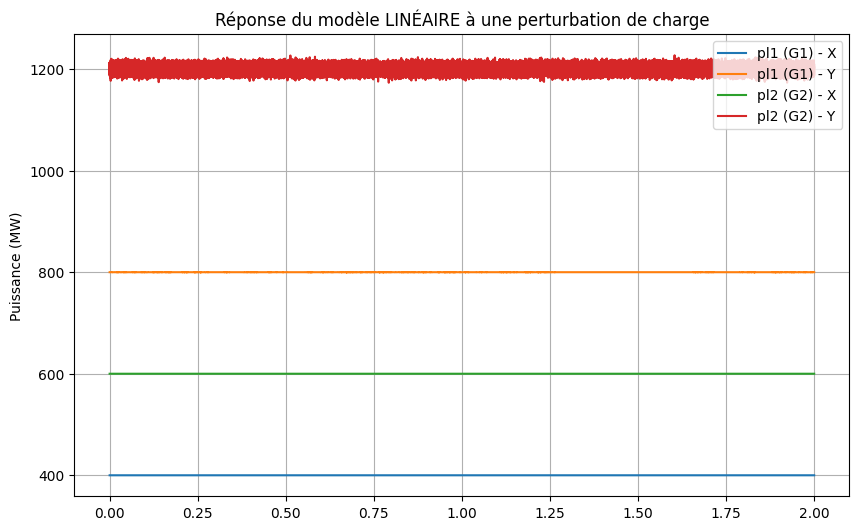

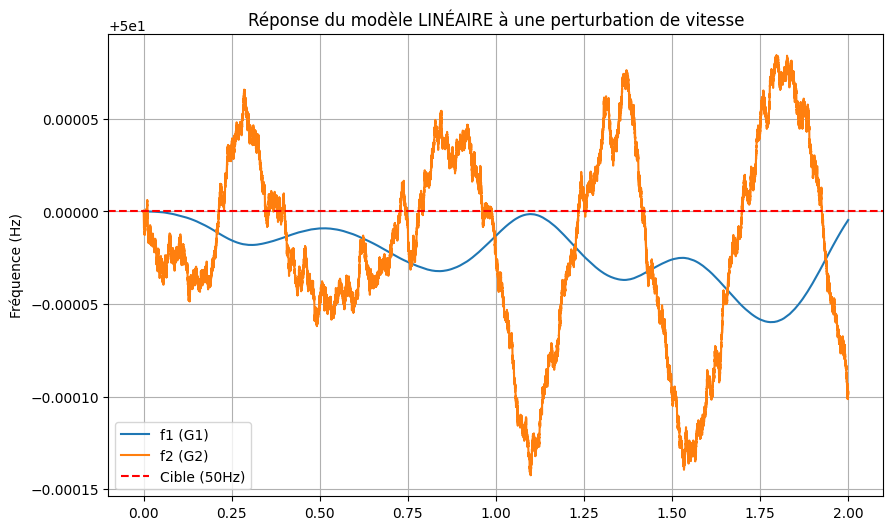

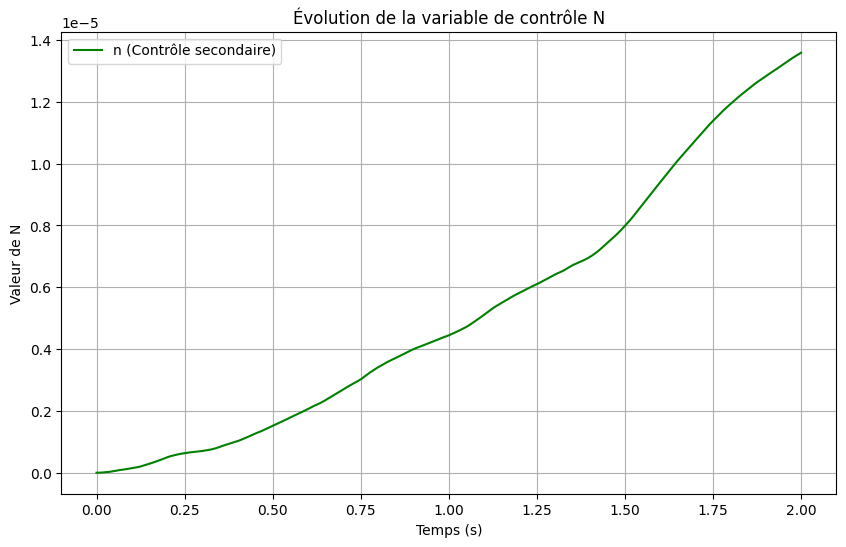

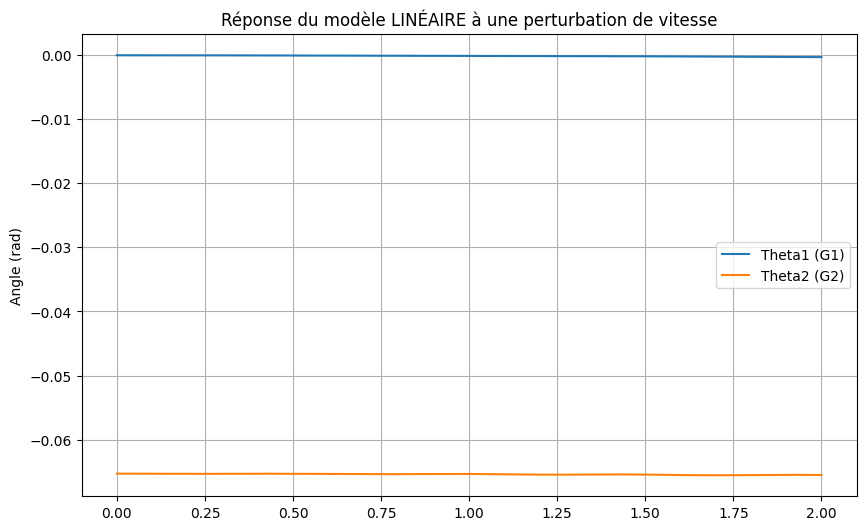

In [23]:

import tqdm
import pandas as pd 

# ---  Initials states ---
x0 = np.array([0, params['omega0'], params['g1']['P0']/params['omega0'], -np.arcsin((params['g1']['P0'] - params['g1']['PL']) / params['KL']), params['omega0'], params['g2']['P0']/params['omega0'], 0, params['g1']['PL'], params['g2']['PL']]) # equilibrium point
#x0 = np.array([0, params['omega0'], params['g1']['P0']/params['omega0'], 0.0, params['omega0'], params['g2']['P0']/params['omega0'], 0]) # Small perturbation on theta2

# --- Equilibrium state ---
x_eq = np.array([0, params['omega0'], params['g1']['P0']/params['omega0'], -np.arcsin((params['g1']['P0'] - params['g1']['PL']) / params['KL']), params['omega0'], params['g2']['P0']/params['omega0'], 0, params['g1']['PL'], params['g2']['PL']])
u_eq = np.array([params['g1']['P0'], params['g2']['P0']])
w_eq = np.array([params['g1']['PL'], params['g2']['PL']])
# w_eq = np.array([0.0, 0.0])

# --- Simulation setup ---
dt = 0.00001  # The time step must be small enough for stability
t_final = 2
t_steps = np.arange(0, t_final, dt)
delta_x0 = x0 - x_eq
x_history = np.zeros((len(t_steps), len(delta_x0)))
x_history[0] = x0
print("Initial state (x0):", x0)
X, Y, A_num, B_num, C_num, D_num, E_num = linear_model(params)
y_final_history = np.zeros((len(t_steps), len(Y)))
y_final_history[0] = C_num @ x0 + E_num @ w_eq
delta_x_current = delta_x0.copy()
delta_u = np.array([0.0, 0.0]) 
delta_w = np.array([0.0, 0.0]) 
print("Senario :", params['scenario'])

# --- Euler's loop ---
for i in tqdm.tqdm(range(1, len(t_steps))):
    
    p1l, p2l, kl = get_disturbances(t_steps[i], params['scenario'], params)
    delta_w = np.array([p1l, p2l]) - w_eq  
    
    # derivation_noise = np.zeros((len(X), 1)) # We assume no model noise for the prediction step
    # derivation_noise[-1] = np.random.normal(i%10-5, 5) # Add small noise to the secondary control state to help observability
    # derivation_noise[-2] = np.random.normal(i%10-5, 5) # Add small noise to the secondary control state to help observability
    
    d_delta_x_dt = A_num @ delta_x_current + B_num @ delta_u + D_num @ delta_w #+ derivation_noise.reshape(-1)

    delta_x_current = delta_x_current + d_delta_x_dt * dt
    x_history[i] = delta_x_current + x_eq
    y_final_history[i, :] = C_num @ x_history[i, :] + E_num @ np.array([p1l, p2l])
    
# --- Post-processing ---
x_final_history = x_history.copy()

x_final_history[:, 1] = x_final_history[:, 1]/(2*np.pi)  # omega1 rad to Hz
x_final_history[:, 4] = x_final_history[:, 4] / (2*np.pi)  # omega2 rad to Hz


# --- df storage ---
df_X = pd.DataFrame(x_final_history, columns=['theta1', 'omega1', 'Tm1', 'theta2', 'omega2', 'Tm2', 'N', 'pl1', 'pl2'])
df_X['time'] = t_steps
df_X.to_csv(f"Res_Sim_LIN_{params['scenario']}.csv", index=False)
# df_X.set_index('time', inplace=True)
df_X.index = pd.to_timedelta(df_X['time'], unit='s')
df_X.drop(columns=['time'], inplace=True)  # Remove time column for noise addition


df_Y = pd.DataFrame(y_final_history, columns=['theta1', 'theta2', 'f12', 'pg1', 'pg2', 'pl1', 'pl2'])
df_Y['time'] = t_steps
df_Y.to_csv(f"Res_Sim_LIN_Y_{params['scenario']}.csv", index=False)
# df_Y.set_index('time', inplace=True)
df_Y.index = pd.to_timedelta(df_Y['time'], unit='s')
df_Y.drop(columns=['time'], inplace=True)  # Remove time column for noise addition

# --- Visualisation ---

plt.figure(figsize=(10, 6))

plt.plot(t_steps, x_final_history[:, -2], label='pl1 (G1) - X')
plt.plot(t_steps, y_final_history[:, -2], label='pl1 (G1) - Y')
plt.plot(t_steps, x_final_history[:, -1], label='pl2 (G2) - X')
plt.plot(t_steps, y_final_history[:, -1], label='pl2 (G2) - Y')
plt.title("Réponse du modèle LINÉAIRE à une perturbation de charge")
plt.ylabel("Puissance (MW)")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 6))

plt.plot(t_steps, x_final_history[:, 1], label='f1 (G1)')
plt.plot(t_steps, x_final_history[:, 4], label='f2 (G2)')
plt.axhline(y=params['omega0'] / (2*np.pi), color='r', linestyle='--', label='Cible (50Hz)')
plt.title("Réponse du modèle LINÉAIRE à une perturbation de vitesse")
plt.ylabel("Fréquence (Hz)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_steps, x_final_history[:, 6], label='n (Contrôle secondaire)', color='green')
plt.title("Évolution de la variable de contrôle N")
plt.xlabel("Temps (s)")
plt.ylabel("Valeur de N")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_steps, x_final_history[:, 0], label='Theta1 (G1)')
plt.plot(t_steps, x_final_history[:, 3], label='Theta2 (G2)')
plt.title("Réponse du modèle LINÉAIRE à une perturbation de vitesse")
plt.ylabel("Angle (rad)")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# import plotly.express as px
# import plotly.graph_objects as go

# # --- Visualisation avec Plotly Express ---

# # Plot 1 : Puissances de charge
# df_plot1 = pd.DataFrame({
#     'time': t_steps,
#     'pl1 (G1) - X': x_final_history[:, -2],
#     'pl1 (G1) - Y': y_final_history[:, -2],
#     'pl2 (G2) - X': x_final_history[:, -1],
#     'pl2 (G2) - Y': y_final_history[:, -1],
# })
# df_plot1_melted = df_plot1.melt(id_vars='time', var_name='Signal', value_name='Puissance (MW)')
# fig1 = px.line(df_plot1_melted, x='time', y='Puissance (MW)', color='Signal',
#                title="Réponse du modèle LINÉAIRE à une perturbation de charge")
# fig1.show()

# # Plot 2 : Fréquences
# df_plot2 = pd.DataFrame({
#     'time': t_steps,
#     'f1 (G1)': x_final_history[:, 1],
#     'f2 (G2)': x_final_history[:, 4],
# })
# df_plot2_melted = df_plot2.melt(id_vars='time', var_name='Signal', value_name='Fréquence (Hz)')
# fig2 = px.line(df_plot2_melted, x='time', y='Fréquence (Hz)', color='Signal',
#                title="Réponse du modèle LINÉAIRE à une perturbation de vitesse")
# fig2.add_hline(y=params['omega0'] / (2 * np.pi), line_dash='dash', line_color='red',
#                annotation_text='Cible (50Hz)', annotation_position='top right')
# fig2.show()

# # Plot 3 : Variable de contrôle N
# df_plot3 = pd.DataFrame({'time': t_steps, 'N': x_final_history[:, 6]})
# fig3 = px.line(df_plot3, x='time', y='N', color_discrete_sequence=['green'],
#                title="Évolution de la variable de contrôle N",
#                labels={'N': 'Valeur de N', 'time': 'Temps (s)'})
# fig3.show()

# # Plot 4 : Angles
# df_plot4 = pd.DataFrame({
#     'time': t_steps,
#     'Theta1 (G1)': x_final_history[:, 0],
#     'Theta2 (G2)': x_final_history[:, 3],
# })
# df_plot4_melted = df_plot4.melt(id_vars='time', var_name='Signal', value_name='Angle (rad)')
# fig4 = px.line(df_plot4_melted, x='time', y='Angle (rad)', color='Signal',
#                title="Réponse du modèle LINÉAIRE à une perturbation d'angle")
# fig4.show()

### 5. Kalman Filter implementation

In [25]:
from tqdm import tqdm
from scipy.linalg import expm

# --- Discretisation ---
dt_Kalman = 0.0001 # The time step must be small enough for stability
Ad = np.eye(len(X)) + A_num * dt_Kalman  # Euler's method for discretization
Ad = expm(A_num * dt_Kalman)  # Matrix exponential for better accuracy
# I = np.eye(len(A_num))
# Ad = np.linalg.inv(I - (dt/2) * A_num) @ (I + (dt/2) * A_num) # Bilinear (Tustin) method for improved stability
# Ad = I + A_num * dt + 0.5 * (A_num * dt) @ (A_num * dt) # Higher-order Taylor expansion for better accuracy
Bd = B_num * dt_Kalman
Dd = D_num * dt_Kalman
C_obs = C_num  
E_obs = E_num * 0.0 # Since E_num is not used, we set it to zero

# --- Add noise to measurements ---
df_Y_noisy = df_Y.copy()
df_Y_noisy = df_Y_noisy.resample(f'{dt_Kalman}s').interpolate(method='linear')  # Resample to match dt
# snr_db = 40 # Signal-to-Noise Ratio in dB
# signal_power_per_channel = np.mean(df_Y_noisy**2, axis=0)
# snr_linear = 10**(snr_db / 10)
# noise_power_per_channel = signal_power_per_channel / snr_linear
# sigma_noise_per_channel = np.sqrt(noise_power_per_channel)
# noise = np.random.normal(0, 1, df_Y_noisy.shape) * sigma_noise_per_channel
sigma = abs(0.01 * np.mean(df_Y_noisy.values, axis=0)) # 1% du signal moyen
print("Sigma Noise Y channels :", sigma)
noise = np.random.normal(0, sigma, df_Y_noisy.shape)
df_Y_noisy = df_Y_noisy + noise


# --- Initialisation ---
t_steps_Kalman = df_Y_noisy.index.values
delta_x_hat = delta_x0.copy().reshape(-1, 1) 
x_eq_kalman = x_eq.copy()
y_eq = C_obs @ x_eq_kalman.reshape(-1, 1) + E_obs @ w_eq.reshape(-1, 1)
print("y_eq (output at equilibrium):", y_eq.flatten())
print("x_eq (state at equilibrium):", x_eq_kalman.flatten())
print("w_eq (disturbance at equilibrium):", w_eq.flatten())
P_cov = np.eye(len(X)) * 0.1    # Initial covariance matrix               
delta_x_hat_history = np.zeros((len(t_steps_Kalman), len(X)))
y_hat_history = np.zeros((len(t_steps_Kalman), len(Y)))
du = np.zeros((2, 1))
dw = np.zeros((2, 1))



# --- Filter parameters ---
Q = np.eye(len(X)) * 1  # Model noise (model confidence)
R = np.eye(len(Y)) * 1e-3  # Measure noise (sensors confidence)
R = np.diag(sigma)  # Measure noise (sensors confidence)
# R = np.diag(noise_power_per_channel) # Measure noise (sensors confidence)


#--- Kalman Filter Loop ---
for i in tqdm(range(len(t_steps_Kalman))):
    # p1l, p2l, kl = get_disturbances(t_steps_Kalman[i], params['scenario'], params)
    # dw = df_Y_noisy.iloc[i]['pl1','pl2'].reshape(-1, 1) - np.array([params['g1']['PL'], params['g2']['PL']]).reshape(-1, 1) # Disturbance estimation from noisy measurements    
    delta_y = df_Y_noisy.iloc[i].values.reshape(-1, 1) - y_eq

    # --- Prediction ---
    derivation_noise = np.zeros((len(X), 1)) # We assume no model noise for the prediction step
    derivation_noise[-1] = np.random.normal(0, 5) # Add small noise to the secondary control state to help observability
    derivation_noise[-2] = np.random.normal(0, 5) # Add small noise to the secondary control state to help observability
    delta_x_hat_minus = Ad @ delta_x_hat + derivation_noise + Bd @ du + Dd @ dw
    P_minus = Ad @ P_cov @ Ad.T + Q

    # --- Correction ---
    innovation = delta_y - (C_obs @ delta_x_hat_minus + E_obs @ dw)
    S = C_obs @ P_minus @ C_obs.T + R
    K = P_minus @ C_obs.T @ np.linalg.inv(S)
    
    delta_x_hat = delta_x_hat_minus + K @ innovation
    P_cov = (np.eye(len(X)) - K @ C_obs) @ P_minus

    delta_x_hat_history[i] = delta_x_hat.flatten()
    
    # --- Estimated output ---
    delta_y_hat = C_obs @ delta_x_hat + E_obs @ dw
    y_hat_total = delta_y_hat + y_eq

    y_hat_history[i] = y_hat_total.flatten()
    
df_X_hat = pd.DataFrame(delta_x_hat_history + x_eq.reshape(1, -1), columns=['theta1', 'omega1', 'Tm1', 'theta2', 'omega2', 'Tm2', 'N', 'pl1', 'pl2'])
df_X_hat['omega1'] = df_X_hat['omega1']/(2*np.pi) 
df_X_hat['omega2'] = df_X_hat['omega2']/(2*np.pi)
df_X_hat['time'] = t_steps_Kalman
# df_X_hat.to_csv(f"Res_Sim_Kalman_LIN_{params['scenario']}.csv", index=False)

df_Y_hat = pd.DataFrame(y_hat_history, columns=['theta1', 'theta2', 'f12', 'pg1', 'pg2', 'pl1', 'pl2'])
df_Y_hat['time'] = t_steps_Kalman 
# df_Y_hat.to_csv(f"Res_Sim_Kalman_LIN_Y_{params['scenario']}.csv", index=False)

Sigma Noise Y channels : [1.03953622e-06 6.54268173e-04 2.00149254e+00 1.00014927e+01
 9.99857500e+00 8.00000020e+00 1.20000675e+01]
y_eq (output at equilibrium): [ 0.00000000e+00 -6.53205930e-02  2.00142297e+02  6.00142297e+02
  3.99857703e+02  4.00000000e+02  6.00000000e+02]
x_eq (state at equilibrium): [ 0.00000000e+00  3.14159265e+02  1.90985932e+00 -6.53205930e-02
  3.14159265e+02  1.27323954e+00  0.00000000e+00  4.00000000e+02
  6.00000000e+02]
w_eq (disturbance at equilibrium): [400. 600.]


100%|██████████| 20000/20000 [00:03<00:00, 5608.96it/s]


In [26]:
# import pandas as pd
# import plotly.express as px


# time_vec = t_steps_Kalman 
# cols_y = ['theta1', 'theta2', 'f12', 'pg1', 'pg2', 'pl1', 'pl2']

# df_X = df_X.resample(f'{dt_Kalman}s').interpolate(method='linear') # Resample to match dt
# df_Y = df_Y.resample(f'{dt_Kalman}s').interpolate(method='linear') # Resample to match dt

# # Création des blocs avec l'étiquette 'Type'
# df_y_noisy = df_Y_noisy[cols_y].copy().assign(Type='Noisy', Time=time_vec)
# df_y_kalman = df_Y_hat[cols_y].copy().assign(Type='Kalman', Time=time_vec)
# df_y_real = df_Y[cols_y].copy().assign(Type='model', Time=time_vec)

# # Fusion verticale
# df_master_y = pd.concat([df_y_real, df_y_noisy, df_y_kalman], axis=0)

# # Transformation en format "Long" pour Plotly Express
# df_y_long = df_master_y.melt(
#     id_vars=['Time', 'Type'], 
#     var_name='Signal', 
#     value_name='Value'
# )

# cols_x = ['theta1', 'omega1', 'Tm1', 'theta2', 'omega2', 'Tm2', 'N']

# df_x_real = df_X[cols_x].copy().assign(Type='model', Time=time_vec)
# df_x_kalman = df_X_hat[cols_x].copy().assign(Type='Kalman', Time=time_vec)

# df_master_x = pd.concat([df_x_real, df_x_kalman], axis=0)
# df_x_long = df_master_x.melt(id_vars=['Time', 'Type'], var_name='State', value_name='Value')

In [27]:
# fig = px.line(
#     df_y_long.query("Signal == 'f12'"), 
#     x='Time', 
#     y='Value', 
#     color='Type',
#     title="Signal Analysis: F12 (Exchanged Power)",
#     labels={'Value': 'Power [p.u.]', 'Time': 'Time [s]', 'Type': 'Legend'},
#     category_orders={'Type': ['Noisy', 'Kalman', 'model']},
#     color_discrete_map={
#         'Noisy': 'silver', # Measured signal with noise
#         'Kalman': 'red',    # Estimated signal
#         'model': 'green'  # True simulated signal 
#     }
# )
# fig.show()

In [28]:

# fig_pg1 = px.line(
#     df_y_long.query("Signal == 'pg1'"), 
#     x='Time', y='Value', color='Type',
#     title="Signal Analysis: PG1 (Generated Power - G1)",
#     labels={'Value': 'Power [p.u.]', 'Time': 'Time [s]', 'Type': 'Legend'},
#     category_orders={'Type': ['Noisy', 'Kalman', 'model']},
#     color_discrete_map={'model': 'green', 'Noisy': 'silver', 'Kalman': 'red'}
# )
# fig_pg1.update_layout(template='plotly_white', hovermode='x unified')
# fig_pg1.show()

In [29]:

# fig_pl1 = px.line(
#     df_y_long.query("Signal == 'pl1'"), 
#     x='Time', y='Value', color='Type',
#     title="Signal Analysis: PL1 (Load Disturbance)",
#     labels={'Value': 'Power [p.u.]', 'Time': 'Time [s]', 'Type': 'Legend'},
#     category_orders={'Type': ['Noisy', 'model', 'Kalman']},
#     color_discrete_map={'model': 'green', 'Noisy': 'silver', 'Kalman': 'red'}
# )
# fig_pl1.update_layout(template='plotly_white', hovermode='x unified')
# fig_pl1.show()

In [30]:

# fig_omega1 = px.line(
#     df_x_long.query("State == 'omega1'"), 
#     x='Time', y='Value', color='Type',
#     title="State Analysis: Omega 1 (Angular Velocity)",
#     labels={'Value': 'Speed [rad/s]', 'Time': 'Time [s]', 'Type': 'Legend'},
#     category_orders={'Type': [ 'Kalman', 'model']},
#     color_discrete_map={'model': 'green', 'Kalman': 'red'} 
# )
# fig_omega1.update_layout(template='plotly_white', hovermode='x unified')
# fig_omega1.show()

In [31]:
fig_omega2 = px.line(
    df_x_long.query("State == 'omega2'"), 
    x='Time', y='Value', color='Type',
    title="State Analysis: Omega 2 (Angular Velocity)",
    labels={'Value': 'Speed [rad/s]', 'Time': 'Time [s]', 'Type': 'Legend'},
    color_discrete_map={'model': 'green', 'Kalman': 'red'} 
)
fig_omega2.update_layout(template='plotly_white', hovermode='x unified')
fig_omega2.show()

In [32]:
# fig_N = px.line(
#     df_x_long.query("State == 'N'"), 
#     x='Time', y='Value', color='Type',
#     title="State Analysis: N (Secondary Control Signal)",
#     labels={'Value': 'N', 'Time': 'Time [s]', 'Type': 'Legend'},
#     color_discrete_map={'model': 'green', 'Kalman': 'red'} 
# )
# fig_N.update_layout(template='plotly_white', hovermode='x unified')
# fig_N.show()